# 22_因果机器学习-因果树与因果森林

## Notebook 使用说明

这是因果学习系列的第 16 份，也是“22. 因果机器学习”的第 6 份。建议先阅读《04. 条件平均处理效应与元学习器》和《05. DR-Learner与R-Learner》，并复习网站中的回归树与随机森林。需要 NumPy、pandas、Matplotlib、SciPy、scikit-learn 和 EconML：`python -m pip install numpy pandas matplotlib scipy scikit-learn econml==0.17.0`。

主线依据参考资料 [2] 第 14.3 节：诚实估计、森林相似性权重、局部矩方程，以及 CATE 的逐点区间。[1] 提供潜在结局和组间均值差的基础。本文仍用 $X$ 表示完整调整变量、$T$ 表示二元处理；主森林将全部 $X$ 同时用于调整与效应建模，不另换目标人群。

先手写一个只分裂一次的因果树桩，再用 EconML 的 `CausalForest` 和 `RegressionForest`。树桩使用书中的异质性代理准则，不是 [3] 原论文带方差惩罚、剪枝和交叉验证的完整因果树。软件部分手动交叉拟合辅助模型，再调用 GRF；不把普通随机森林改名为因果森林，也不把 DR 森林与残差型因果森林混作一个算法。[4–5]

小表、零效应筛选实验、非线性主模拟和两道练习均为本篇的教学构造，不复现书中的 401(k) 或 Welfare 数值。数据由代码生成，不读取外部文件，也不依赖前面 Notebook 的变量。默认做 800 次树桩筛选实验，并在 800 人和 2,400 人两种样本量下各做 120 次完整的独立训练样本模拟。测试点不参与拟合或调参；输出与图形均已保存。重新运行请使用 Restart Kernel and Run All Cells。

In [1]:
# 环境初始化：只生成数据，限制计算线程，不屏蔽数值或模型拟合警告。
import os
import sys
import tempfile
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display
import scipy
from scipy.special import expit
from scipy.stats import norm
import sklearn
from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestRegressor
import econml
from econml.grf import CausalForest, RegressionForest
from threadpoolctl import threadpool_limits

%matplotlib inline

_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [
    f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei",
                "SimHei", "Noto Sans CJK SC", "Noto Sans CJK JP"]
    if f in _available_fonts
] + ["DejaVu Sans"]
plt.rcParams.update({
    "font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
    "figure.dpi": 100, "figure.max_open_warning": 30,
})
pd.set_option("display.max_columns", 12)
pd.set_option("display.width", 150)
_thread_limit = threadpool_limits(limits=1)

SEED_DATA = 42
SEED_TEST = 2026
SEED_SPLIT = 2026
SEED_HONEST = 5100
SEED_REPEAT = 6100
SEED_FOREST = 99
N_MAIN = 2000
N_TEST = 5000
N_FOLDS = 5
N_TREES = 400
N_HONEST_REPEATS = 800
SAMPLE_SIZES = (800, 2400)
N_REPEATS = 120
N_MC_TREES = 160
CLIP = 0.01
Z_CRIT = norm.ppf(0.975)
X_COLS = ["X1", "X2", "X3"]
# 在任何模型拟合前，固定用于检查逐点覆盖率的位置。
CHECK_POINTS = np.zeros((5, 3))
CHECK_POINTS[:, 0] = [-0.8, -0.4, 0.0, 0.4, 0.8]
GRID = np.zeros((161, 3))
GRID[:, 0] = np.linspace(-0.95, 0.95, len(GRID))

if min(N_HONEST_REPEATS, N_REPEATS) < 2:
    raise ValueError("重复模拟至少需要两次。")
print(f"Python {sys.version.split()[0]}")
print(f"NumPy {np.__version__} | pandas {pd.__version__} | Matplotlib {plt.matplotlib.__version__}")
print(f"SciPy {scipy.__version__} | scikit-learn {sklearn.__version__} | EconML {econml.__version__}")

Python 3.13.5
NumPy 2.3.5 | pandas 2.2.3 | Matplotlib 3.10.8
SciPy 1.17.0 | scikit-learn 1.8.0 | EconML 0.17.0


上一篇把 DR 伪结局或两侧残差交给回归器，学习一条效应曲线。这次专门看树：一个切分为什么有助于发现处理效应？又为什么不能用同一群人既挑切分、又给挑中的差异计算普通区间？

先保留最小的树结构，只分成两个叶节点。随后把很多棵树转换为“哪些训练样本与目标点相似”的权重，直接核对软件的最终计算。

## 理论基础

### 1. 预测结局的树，不一定在找效应差异

目标仍是

$$
\tau(x)=E[Y(1)-Y(0)\mid X=x].
$$

在一致性、无干扰、给定完整 $X$ 后的条件可忽略性，以及相应的重叠条件下，它等于同一 $x$ 下的两种条件均值之差。这里没有观测到个人效应标签；CATE 的区间也不是某个人两个潜在结局之差的预测区间。[1，第 2、10 章；2，第 14.1 节]

普通回归树的切分让叶内结局更相似。设父节点为 $P$，切成 $L,R$，平方误差下降量为

$$
\Delta_Y=\sum_{C\in\{L,R\}}n_C(\overline Y_C-\overline Y_P)^2.
$$

但某个变量可能让所有人的收入都高一些，却完全不改变培训的作用。按它分裂，可以改善收入预测，却没有分出不同的培训效应。

下面是 16 行教学数据：$X_1$ 只改变基线，$X_2$ 才改变处理效应。每种 $(X_1,X_2,T)$ 组合各两行，噪声为 $-0.2,0.2$，两组在每个组合上都平衡。

In [2]:
from itertools import product

tiny = pd.DataFrame(
    [(x1, x2, t, err) for x1, x2, t in product([0, 1], repeat=3)
     for err in [-0.2, 0.2]],
    columns=["X1", "X2", "T", "noise"],
)
tiny["Y"] = 10*tiny["X1"] + tiny["T"]*(1 + 2*tiny["X2"]) + tiny["noise"]
display(tiny[["X1", "X2", "T", "Y"]])
display(tiny.groupby(["X1", "X2", "T"])["Y"].mean().unstack("T"))

,X1,X2,T,Y
0,0,0,0,-0.2
1,0,0,0,0.2
2,0,0,1,0.8
3,0,0,1,1.2
4,0,1,0,-0.2
5,0,1,0,0.2
6,0,1,1,2.8
7,0,1,1,3.2
8,1,0,0,9.8
9,1,0,0,10.2


T         0     1
X1 X2            
0  0    0.0   1.0
   1    0.0   3.0
1  0   10.0  11.0
   1   10.0  13.0

### 2. 把切分目标换成效应异质性

在这个平衡的小表中，叶节点的处理效应用组间均值差估计：

$$
\widehat\tau_C=\overline Y_{C,T=1}-\overline Y_{C,T=0}.
$$

按照书中 GRF 的异质性代理准则，对每个候选切分计算

$$
Q_\tau(L,R)=\frac{n_L\widehat\tau_L^2+n_R\widehat\tau_R^2}{n_P}
-\widehat\tau_P^2.
$$

对同一父节点，最后一项是常数，不改变排序。它倾向于将不同效应分开，而不是仅分开不同水平的结局。[2，正文第 388 页]

下面遍历候选特征与阈值，要求每个子节点的人数至少占父节点的一定比例，而且两种处理各有足够样本。真实观察性数据不能直接照搬这里的叶内均值差：后面先调整混杂，再解局部矩方程。

本例只演示切分目标。尚未加入完整因果树的方差惩罚与剪枝；在同一份数据上选择最大的 $Q_\tau$，仍会把偶然的差异挑出来。

In [3]:
def checked_data(X,T,Y):
    X=np.asarray(X,dtype=float);T=np.asarray(T,dtype=float);Y=np.asarray(Y,dtype=float)
    if X.ndim!=2 or T.ndim!=1 or Y.ndim!=1 or len(X)!=len(T) or len(T)!=len(Y):
        raise ValueError('X 为二维矩阵，T、Y 为等长的一维数组。')
    if len(Y)<4 or X.shape[1]<1 or not all(np.isfinite(z).all() for z in (X,T,Y)):
        raise ValueError('至少四行、一列特征，且不能包含缺失或无穷值。')
    if not np.isin(T,[0.,1.]).all() or np.unique(T).size!=2:
        raise ValueError('T 必须同时包含 0 和 1。')
    return X,T,Y

def group_difference(T,Y):
    T=np.asarray(T);Y=np.asarray(Y,float)
    if T.ndim!=1 or Y.ndim!=1 or len(T)!=len(Y) or not np.isin(T,[0,1]).all() or not np.isfinite(Y).all():
        raise ValueError('需要有效的二元处理与有限结局。')
    y0=Y[T==0];y1=Y[T==1]
    if min(len(y0),len(y1))<2:
        raise ValueError('每组至少两人，才能计算本例的样本方差。')
    estimate=y1.mean()-y0.mean()
    variance=y1.var(ddof=1)/len(y1)+y0.var(ddof=1)/len(y0)
    return dict(n=len(Y), n0=len(y0), n1=len(y1), effect=estimate, se=np.sqrt(variance))

def split_candidates(X,T,Y,quantiles=(.2,.3,.4,.5,.6,.7,.8),min_arm=8,min_fraction=.2):
    X,T,Y=checked_data(X,T,Y)
    if min_arm<2 or not 0<min_fraction<=.5:
        raise ValueError('min_arm 至少为 2，min_fraction 应在 (0, 0.5]。')
    if len(quantiles)==0 or np.any((np.asarray(quantiles)<=0)|(np.asarray(quantiles)>=1)):
        raise ValueError('候选分位点应在 (0,1)。')
    parent=group_difference(T,Y);n=len(Y);records=[]
    for j in range(X.shape[1]):
        vals=np.unique(X[:,j]);cuts=np.unique(np.quantile(X[:,j],quantiles))
        if len(vals)<=3:
            cuts=(vals[:-1]+vals[1:])/2
        for cut in cuts:
            left=X[:,j]<=cut;right=~left
            if min(left.sum(),right.sum())<n*min_fraction:
                continue
            if min(np.sum(left&(T==0)),np.sum(left&(T==1)),np.sum(right&(T==0)),np.sum(right&(T==1)))<min_arm:
                continue
            a=group_difference(T[left],Y[left]);b=group_difference(T[right],Y[right])
            gain=(a['n']*a['effect']**2+b['n']*b['effect']**2)/n-parent['effect']**2
            outcome_gain=(left.sum()*(Y[left].mean()-Y.mean())**2+right.sum()*(Y[right].mean()-Y.mean())**2)/n
            records.append(dict(feature=j,cut=float(cut),n_left=a['n'],n_right=b['n'],effect_left=a['effect'],effect_right=b['effect'],effect_gain=gain,outcome_gain=outcome_gain))
    if not records:
        raise ValueError('没有满足两组人数与分裂平衡约束的候选切分。')
    return pd.DataFrame(records)

def choose_stump(X,T,Y,**kwargs):
    table=split_candidates(X,T,Y,**kwargs)
    # 稳定排序使并列候选有固定的选择顺序。
    best=table.sort_values(['effect_gain','feature','cut'],ascending=[False,True,True],kind='stable').iloc[0]
    return {'feature':int(best['feature']),'cut':float(best['cut'])}, table

def estimate_stump(stump,X,T,Y):
    X,T,Y=checked_data(X,T,Y)
    j=stump['feature'];cut=stump['cut']
    if not 0<=j<X.shape[1] or not np.isfinite(cut):
        raise ValueError('无效的树桩。')
    left=X[:,j]<=cut
    stats=[group_difference(T[left],Y[left]),group_difference(T[~left],Y[~left])]
    table=pd.DataFrame(stats,index=['left','right'])
    gap=stats[1]['effect']-stats[0]['effect'];se=np.hypot(stats[0]['se'],stats[1]['se'])
    return table,dict(gap=gap,se=se,z=gap/se)

tiny_scores = split_candidates(
    tiny[["X1", "X2"]].to_numpy(), tiny["T"].to_numpy(), tiny["Y"].to_numpy(),
    min_arm=2, min_fraction=0.2,
)
tiny_scores["特征"] = tiny_scores["feature"].map({0: "X1：基线", 1: "X2：效应"})
display(tiny_scores[["特征", "cut", "effect_left", "effect_right", "outcome_gain", "effect_gain"]].round(4))
print("按结局预测切分：", tiny_scores.loc[tiny_scores.outcome_gain.idxmax(), "特征"])
print("按效应异质性切分：", tiny_scores.loc[tiny_scores.effect_gain.idxmax(), "特征"])

,特征,cut,effect_left,effect_right,outcome_gain,effect_gain
0,X1：基线,0.5,2.0,2.0,25.00,0.0
1,X2：效应,0.5,1.0,3.0,0.25,1.0


按结局预测切分： X1：基线
按效应异质性切分： X2：效应


按 $X_1$ 切分，两侧效应都是 2；按 $X_2$ 切分，两侧效应是 1 和 3。前者的结局均值相差 10，但没有效应差异。两列分数分别对应不同目标，不能把数值更大的一列当成“更好的算法”。

### 3. 诚实估计：先把“挑差异”和“量差异”分开

诚实树将样本分成两部分：结构样本决定切分，估计样本只在固定的叶节点中计算结果。对一棵树而言，这两部分不能重合。[2，正文第 386 页；3]

这里让真实效应处处为零，$Y$ 与所有特征、处理均独立。在第一份 400 人数据中，从 6 个特征及其候选阈值里挑一个最有异质性的切分，再分别用原来的 400 人和新的 400 人估计右叶与左叶的效应差：

$$
\widehat\Delta=\widehat\tau_R-\widehat\tau_L,\qquad
\widehat{\mathrm{SE}}(\widehat\Delta)
=\sqrt{\widehat{\mathrm{SE}}(\widehat\tau_R)^2+
       \widehat{\mathrm{SE}}(\widehat\tau_L)^2}.
$$

在这里的独立、随机分配构造下，第二份数据面对的是已经固定的两个叶节点，普通大样本误差计算有依据。第一份数据的误差公式没有计入“从许多切分里挑最大”的过程。比较的是同一个选定对比，不是所有可能切分的同时推断。

,方法,平均绝对效应差,零效应下拒绝比例,MC区间下界,MC区间上界
0,复用结构样本,0.5051,0.7138,0.6815,0.7440
1,独立估计样本,0.1834,0.0612,0.0466,0.0801


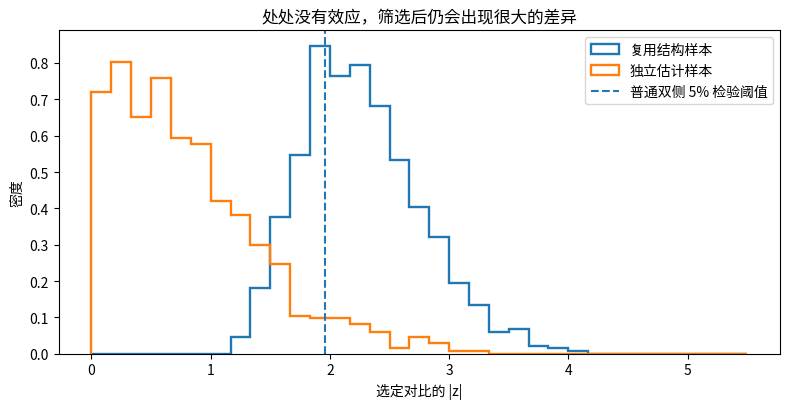

In [4]:
def wilson(success,total,z=1.959963984540054):
    p=np.asarray(success)/total;den=1+z*z/total
    center=(p+z*z/(2*total))/den;half=z*np.sqrt(p*(1-p)/total+z*z/(4*total**2))/den
    return center-half,center+half

honesty_rows = []
for rep in range(N_HONEST_REPEATS):
    rng = np.random.default_rng(SEED_HONEST + rep)
    X_null = rng.uniform(-1, 1, size=(800, 6))
    T_null = rng.binomial(1, 0.5, size=800)
    Y_null = rng.normal(size=800)  # 对任何 X，处理效应都为零。
    stump, _ = choose_stump(X_null[:400], T_null[:400], Y_null[:400], min_arm=12)
    for name, sl in [("复用结构样本", slice(0, 400)), ("独立估计样本", slice(400, 800))]:
        _, answer = estimate_stump(stump, X_null[sl], T_null[sl], Y_null[sl])
        honesty_rows.append({"rep": rep, "method": name, **answer})
honesty = pd.DataFrame(honesty_rows)
honesty_summary = []
for name, part in honesty.groupby("method", sort=False):
    rejected = int((part.z.abs() > Z_CRIT).sum())
    low, high = wilson(rejected, len(part))
    honesty_summary.append({
        "方法": name, "平均绝对效应差": part.gap.abs().mean(),
        "零效应下拒绝比例": rejected/len(part), "MC区间下界": low, "MC区间上界": high,
    })
display(pd.DataFrame(honesty_summary).round(4))

fig, ax = plt.subplots(figsize=(8, 4.2))
for name, part in honesty.groupby("method", sort=False):
    ax.hist(part.z.abs(), bins=np.linspace(0, max(5.5, 1.02*honesty.z.abs().max()), 34), histtype="step", density=True,
            linewidth=1.7, label=name)
ax.axvline(Z_CRIT, linestyle="--", label="普通双侧 5% 检验阈值")
ax.set(xlabel="选定对比的 |z|", ylabel="密度", title="处处没有效应，筛选后仍会出现很大的差异")
ax.legend()
fig.tight_layout()
plt.show()

看表中的拒绝比例：第一种方法把筛选造成的极端值当成预先指定的对比，远不止 5% 的实验会拒绝零假设。第二种接近名义水平，但仍有 Monte Carlo 波动和有限样本近似误差。表中 MC 区间衡量的是这个拒绝比例的模拟精度，不是某一叶节点的效应区间。

诚实估计并不保证一棵树就能准确恢复整条效应函数。它分开了选择与估计，也减少了每个环节的样本量；树的阈值和预测仍会波动。

### 4. 两次分样本，解决的不是同一个问题

前面的交叉拟合防止辅助预测直接使用当前行的结局或处理。树内部的诚实划分则防止当前树用同一行的结果既选结构又估计叶节点。前者不能代替后者。

书中给出的森林推断条件还包括分裂平衡、随机特征切分、适当的叶节点规模、无放回子抽样及辅助模型质量。打开 `honest=True` 并不自动验证所有条件。[2，正文第 386–388 页]

下面用同一组折外预测，构造两类森林：

| 森林 | 输入的结果量 | 最后估计什么 |
|---|---|---|
| DR 森林 | AIPW 伪结局 $\widehat\Gamma$ | 森林邻域内的加权均值 |
| 残差型因果森林 | $a=Y-\widehat\ell(X)$ 与 $b=T-\widehat e(X)$ | 森林邻域内的局部斜率 |

DR 森林对应书中的 Doubly Robust Forest；本篇简称 CF 的因果森林对应其 GRF 残差矩方法，不是所有“因果森林”变体的统称。

## 完整案例一：从折外预测到两种森林

### 1. 数据生成与目标

独立生成 $X_1,X_2,X_3\sim U(-1,1)$，令

$$
\begin{aligned}
e(X)&=\operatorname{expit}(0.8X_1+0.8X_2-0.4X_3),\\
\mu_0(X)&=2+2X_2+1.2X_3^2+0.7X_1X_2,\\
\tau(X)&=1+0.8\sin(\pi X_1),\\
\mu_1(X)&=\mu_0(X)+\tau(X),\\
Y(t)&=\mu_t(X)+0.5(1+0.4X_1^2)\varepsilon_t.
\end{aligned}
$$

两种噪声独立标准正态，处理按 $e(X)$ 分配，且给定 $X$ 后独立于潜在结局。独立噪声只是模拟选择，并不是观察数据能够识别的结论。

$X_2$ 对收入预测很重要，但效应只随 $X_1$ 变化。所有变量都送入辅助模型与森林；“真实答案”单独保存，只用于最后评价。

In [5]:
def make_data(n,seed,overlap=1.0):
    if n<20 or overlap<=0:
        raise ValueError('n 至少为 20，重叠参数必须为正。')
    rng=np.random.default_rng(seed)
    X=rng.uniform(-1,1,size=(n,3))
    x1,x2,x3=X.T
    e=expit(overlap*(.8*x1+.8*x2-.4*x3))
    mu0=2+2*x2+1.2*x3**2+.7*x1*x2
    tau=1+.8*np.sin(np.pi*x1)
    mu1=mu0+tau;sigma=.5*(1+.4*x1**2)
    T=(rng.uniform(size=n)<e).astype(int)
    y0=mu0+sigma*rng.normal(size=n);y1=mu1+sigma*rng.normal(size=n)
    Y=np.where(T==1,y1,y0)
    observed=pd.DataFrame(X,columns=['X1','X2','X3']);observed['T']=T;observed['Y']=Y
    truth=dict(e=e,mu0=mu0,mu1=mu1,tau=tau,ell=mu0+e*tau,sigma=sigma,y0=y0,y1=y1)
    return observed,truth

observed, truth = make_data(N_MAIN, SEED_DATA)
X = observed[X_COLS].to_numpy()
T = observed["T"].to_numpy()
Y = observed["Y"].to_numpy()
test_observed, test_truth = make_data(N_TEST, SEED_TEST)
X_test = test_observed[X_COLS].to_numpy()
TAU_GRID = 1 + 0.8*np.sin(np.pi*GRID[:, 0])
TAU_CHECK = 1 + 0.8*np.sin(np.pi*CHECK_POINTS[:, 0])
display(observed.head(8).round(4))
display(observed.groupby("T")["Y"].agg(["count", "mean", "std"]).round(4))
print("模拟机制中的评分范围：", np.round([truth["e"].min(), truth["e"].max()], 4))
print("训练样本的平均真实 CATE：", round(truth["tau"].mean(), 4))

,X1,X2,X3,T,Y
0,0.5479,-0.1222,0.7172,1,3.9020
1,0.3947,-0.8116,0.9512,1,3.4703
2,0.5223,0.5721,-0.7438,1,5.9414
3,-0.0992,-0.2584,0.8535,1,2.3039
4,0.2877,0.6455,-0.1132,1,4.7177
5,-0.5455,0.1092,-0.8724,1,2.4580
6,0.6553,0.2633,0.5162,0,2.3956
7,-0.2909,0.9414,0.7862,0,4.8024


,count,mean,std
T,,,
0,970,2.0724,1.2868
1,1030,3.7222,1.4552


模拟机制中的评分范围： [0.1233 0.8689]
训练样本的平均真实 CATE： 0.9853


### 2. 先生成辅助预测，不让森林见到真值

预测四个条件均值：$\mu_0,\mu_1,e,\ell$。其中

$$
\ell(X)=E[Y\mid X]=\mu_0(X)+e(X)\tau(X),
$$

不能用 $\mu_0$ 代替。处理模型返回 $T=1$ 的概率，不是分类标签。

本例用四次多项式加 Ridge 拟合结果条件均值，用 Logistic 拟合处理概率。选这些模型是为了使重复模拟运行较快；结果函数含正弦，$\ell$ 又含概率与正弦的乘积，多项式并非完全正确的模型。所有变换和模型都只在相应训练折拟合。

第 $k$ 折中，两种结果模型分别使用训练折中的两组人；处理模型和 $\ell$ 模型使用整个训练折。留出折的每一行得到四项预测。

In [6]:
def nuisance_models():
    reg=make_pipeline(PolynomialFeatures(4,include_bias=False),StandardScaler(),Ridge(alpha=1.0))
    prop=make_pipeline(StandardScaler(),LogisticRegression(C=100.,max_iter=2000,tol=1e-9))
    return reg,prop

def crossfit_nuisance(X,T,Y,n_splits=5,seed=2026,clip=.01):
    X,T,Y=checked_data(X,T,Y)
    if not 2<=n_splits<=min(np.sum(T==0),np.sum(T==1)) or not 0<clip<.5:
        raise ValueError('分折数不能超过较小处理组的人数，clip 应在 (0,0.5)。')
    reg,prop=nuisance_models();n=len(Y)
    pred=np.full((n,4),np.nan);seen=np.zeros(n,int);logs=[];splits=[]
    for k,(itr,ite) in enumerate(StratifiedKFold(n_splits,shuffle=True,random_state=seed).split(X,T)):
        for t in (0,1):
            arm=itr[T[itr]==t]
            pred[ite,t]=clone(reg).fit(X[arm],Y[arm]).predict(X[ite])
        pe=clone(prop).fit(X[itr],T[itr]);class1=np.flatnonzero(pe.classes_==1).item()
        pred[ite,2]=pe.predict_proba(X[ite])[:,class1]
        pred[ite,3]=clone(reg).fit(X[itr],Y[itr]).predict(X[ite])
        seen[ite]+=1;splits.append((itr.copy(),ite.copy()))
        logs.append(dict(fold=k+1,train=len(itr),train0=int(np.sum(T[itr]==0)),train1=int(np.sum(T[itr]==1)),heldout=len(ite),intersection=len(np.intersect1d(itr,ite))))
    if not np.all(seen==1) or not np.isfinite(pred).all():
        raise RuntimeError('折外预测没有完整且唯一地覆盖每一行。')
    frame=pd.DataFrame(pred,columns=['mu0_hat','mu1_hat','e_raw','ell_hat'])
    frame['e_hat']=np.clip(frame.e_raw,clip,1-clip)
    return frame,pd.DataFrame(logs),splits

def signals(T,Y,pred):
    T=np.asarray(T,float);Y=np.asarray(Y,float)
    e=np.asarray(pred['e_hat']);m0=np.asarray(pred['mu0_hat']);m1=np.asarray(pred['mu1_hat']);ell=np.asarray(pred['ell_hat'])
    if not all(len(z)==len(T) for z in (Y,e,m0,m1,ell)) or not all(np.isfinite(z).all() for z in (T,Y,e,m0,m1,ell)) or not np.all((e>0)&(e<1)):
        raise ValueError('输入必须等长、有限，评分严格处于 (0,1)。')
    a=Y-ell;b=T-e
    gamma=m1-m0+T*(Y-m1)/e-(1-T)*(Y-m0)/(1-e)
    return a,b,gamma

pred, fold_audit, outer_splits = crossfit_nuisance(X, T, Y, N_FOLDS, SEED_SPLIT, CLIP)
a, b, gamma = signals(T, Y, pred)
display(fold_audit)
preview = observed[["T", "Y"]].join(pred[["mu0_hat", "mu1_hat", "e_hat", "ell_hat"]])
preview = preview.assign(a=a, b=b, Gamma=gamma)
display(preview.head(8).round(4))
print("发生评分截断的行数：", int((pred.e_raw != pred.e_hat).sum()))

,fold,train,train0,train1,heldout,intersection
0,1,1600,776,824,400,0
1,2,1600,776,824,400,0
2,3,1600,776,824,400,0
3,4,1600,776,824,400,0
4,5,1600,776,824,400,0


,T,Y,mu0_hat,mu1_hat,e_hat,ell_hat,a,b,Gamma
0,1,3.9020,2.2127,4.2054,0.5769,3.1623,0.7397,0.4231,1.4668
1,1,3.4703,1.0568,3.1073,0.3335,1.5362,1.9341,0.6665,3.1389
2,1,5.9414,3.7392,5.6743,0.7783,5.3149,0.6265,0.2217,2.2783
3,1,2.3039,2.2880,3.1092,0.3838,2.6131,-0.3092,0.6162,-1.2769
4,1,4.7177,3.3592,4.9973,0.7221,4.6389,0.0788,0.2779,1.2510
5,1,2.4580,3.0941,3.1672,0.4930,3.1157,-0.6577,0.5070,-1.3655
6,0,2.3956,2.9395,4.6138,0.6791,4.0927,-1.6971,-0.6791,3.3690
7,0,4.8024,4.3784,5.0764,0.6172,4.9258,-0.1233,-0.6172,-0.4098


发生评分截断的行数： 0


DR 标签是

$$
\widehat\Gamma_i=\widehat\mu_1(X_i)-\widehat\mu_0(X_i)
+\frac{T_i\{Y_i-\widehat\mu_1(X_i)\}}{\widehat e(X_i)}
-\frac{(1-T_i)\{Y_i-\widehat\mu_0(X_i)\}}{1-\widehat e(X_i)}.
$$

`Gamma` 不会等于每个人的真实效应。它带有较大的噪声；有时甚至是负数，而本例所有 CATE 都为正。第二阶段是在学习这些信号的条件平均。

先检查两侧残差和辅助预测。模拟里能查看函数误差；真实研究只能直接检查事实结局的折外预测误差，不能把未观测反事实当成测试标签。

In [7]:
nuisance_checks = pd.DataFrame([
    {"预测对象": "mu0", "模拟函数 MSE（全体 X）": np.mean((pred.mu0_hat-truth["mu0"])**2),
     "事实折外 MSE": np.mean((Y[T==0]-pred.mu0_hat.to_numpy()[T==0])**2)},
    {"预测对象": "mu1", "模拟函数 MSE（全体 X）": np.mean((pred.mu1_hat-truth["mu1"])**2),
     "事实折外 MSE": np.mean((Y[T==1]-pred.mu1_hat.to_numpy()[T==1])**2)},
    {"预测对象": "ell", "模拟函数 MSE（全体 X）": np.mean((pred.ell_hat-truth["ell"])**2),
     "事实折外 MSE": np.mean(a**2)},
    {"预测对象": "e", "模拟函数 MSE（全体 X）": np.mean((pred.e_hat-truth["e"])**2),
     "事实折外 MSE": np.mean(b**2)},
])
display(nuisance_checks.round(5))
display(pd.DataFrame({"a": a, "b": b, "Gamma": gamma}).describe().round(4))

,预测对象,模拟函数 MSE（全体 X）,事实折外 MSE
0,mu0,0.01897,0.32701
1,mu1,0.02090,0.34528
2,ell,0.01607,0.64185
3,e,0.00097,0.22050


,a,b,Gamma
count,2000.0000,2000.0000,2000.0000
mean,0.0002,0.0004,1.0124
std,0.8014,0.4697,1.3479
min,-2.3293,-0.8922,-5.7369
25%,-0.5415,-0.4493,0.1723
50%,0.0129,0.1662,1.0362
75%,0.5671,0.4240,1.8635
max,2.8442,0.8617,10.4483


### 3. DR 森林：预测的是伪结局的条件均值

设第 $s$ 棵树中，目标点 $x$ 落在叶节点 $L_s(x)$。只计该树的估计样本 $E_s$，定义

$$
\alpha_i(x)=\frac1B\sum_{s=1}^B
\frac{\mathbf 1\{i\in E_s,\ X_i\in L_s(x)\}}
     {\#\{j\in E_s:X_j\in L_s(x)\}}.
$$

每棵树给同叶的估计样本相等权重，再跨树平均。因此 $\alpha_i(x)\ge0$、$\sum_i\alpha_i(x)=1$。DR 森林的结果为

$$
\widehat\tau_{\mathrm{DRF}}(x)=\sum_i\alpha_i(x)\widehat\Gamma_i.
$$

这组权重不是预先给定的欧氏距离核，而是由树学出来的邻域。[2，正文第 386、389 页]

### 4. 因果森林：使用邻域，解局部矩方程

在辅助函数取真值时，

$$
E[(a-\tau(x)b)b\mid X=x]=0.
$$

本篇软件设置 `fit_intercept=True`，同时估计局部截距 $\beta(x)$：

$$
\sum_i\alpha_i(x)
\begin{pmatrix}b_i\\1\end{pmatrix}
[a_i-\tau(x)b_i-\beta(x)]=0.
$$

令 $q_i=(b_i,1)^\top$，先汇总

$$
J(x)=\sum_i\alpha_i(x)q_iq_i^\top,\qquad
A(x)=\sum_i\alpha_i(x)q_i a_i,
$$

再解 $J(x)(\widehat\tau(x),\widehat\beta(x))^\top=A(x)$。等价地，斜率是局部加权协方差除以局部加权方差；不能直接套没有截距的比值。[2，式 (14.3.3)–(14.3.5)、正文第 391 页]

GRF 汇总的是矩方程，不是各棵树的斜率。因此“每棵树预测一个斜率，再求平均”一般不会得到相同结果。后面从软件记录的叶节点重新计算这些权重，直接核对。

下面每棵树无放回抽取 45% 的样本，在树内分开结构与估计样本。`min_balancedness_tol=0.3` 对应最小子节点比例 $0.5-0.3=0.2$。参数在看测试结果前固定。CF 使用异质性代理准则 `het`；DRF 对伪结局使用回归分裂。两类森林学到的邻域不必相同。[4–5]

In [8]:
def forest_parameters(n_trees=400,min_leaf=20,seed=99,inference=True,honest=True):
    if n_trees<8 or (inference and n_trees%4):
        raise ValueError('本篇至少 8 棵树；开启推断时树数需被 subforest_size=4 整除。')
    return dict(n_estimators=n_trees,min_samples_leaf=min_leaf,min_samples_split=2*min_leaf,
                max_depth=None,max_samples=.45,min_balancedness_tol=.3,max_features=1.0,
                honest=honest,inference=inference,subforest_size=4,n_jobs=1,random_state=seed)

def fit_forests(X,a,b,gamma,n_trees=400,min_leaf=20,seed=99):
    params=forest_parameters(n_trees,min_leaf,seed)
    cf=CausalForest(criterion='het',fit_intercept=True,min_var_fraction_leaf=.05,**params).fit(X,b,a)
    drf=RegressionForest(**params).fit(X,gamma)
    return cf,drf

def get_interval(forest,X):
    point,lower,upper=forest.predict(X,interval=True,alpha=.05)
    return point[:,0],lower[:,0],upper[:,0]

cf, drf = fit_forests(X, a, b, gamma, N_TREES, min_leaf=20, seed=SEED_FOREST)
# 普通预测森林采用 S-Learner 路径：在同一 X 下切换 T，取预测差。
s_forest = RandomForestRegressor(
    n_estimators=N_TREES, min_samples_leaf=20, max_features=1.0,
    n_jobs=1, random_state=SEED_FOREST,
).fit(np.column_stack([X, T]), Y)

def s_effect(model, features):
    features = np.asarray(features, float)
    return (model.predict(np.column_stack([features, np.ones(len(features))]))
            - model.predict(np.column_stack([features, np.zeros(len(features))])))

pred_test = {"预测森林 S": s_effect(s_forest, X_test),
             "因果森林 CF": cf.predict(X_test)[:, 0],
             "DR 森林": drf.predict(X_test)[:, 0]}
comparison = pd.DataFrame([
    {"方法": name, "测试 CATE RMSE": np.sqrt(np.mean((value-test_truth["tau"])**2)),
     "测试人群平均预测效应": value.mean(),
     "平均效应误差": value.mean()-test_truth["tau"].mean()}
    for name, value in pred_test.items()
])
display(comparison.round(5))

,方法,测试 CATE RMSE,测试人群平均预测效应,平均效应误差
0,预测森林 S,0.29550,1.01323,0.01590
1,因果森林 CF,0.10501,1.03516,0.03783
2,DR 森林,0.09965,1.02968,0.03235


这里三种方法都在估计相同 CATE，测试特征与真值不参与训练。普通预测森林并非不能估计效应；它只是主要为结局预测分配切分资源。一次拟合的排序也不代表普遍优劣。

### 5. 逐点区间与切片曲线

EconML 的森林推断使用小袋子 Bootstrap 一类的方差估计及相应修正，不是拿树间标准差除以树数平方根。[4–5] 本篇直接调用软件区间，随后用重复样本检查其表现，不以“软件返回了区间”替代验证。

画图时固定 $X_2=X_3=0$，只改变 $X_1$。这是 CATE 的切片，不是对其他变量做条件平均；本例真效应恰好只依赖 $X_1$，两者才一致。浅色区域连接的是每个预先指定位置的 95% 区间，不是整条函数同时覆盖 95% 的带。

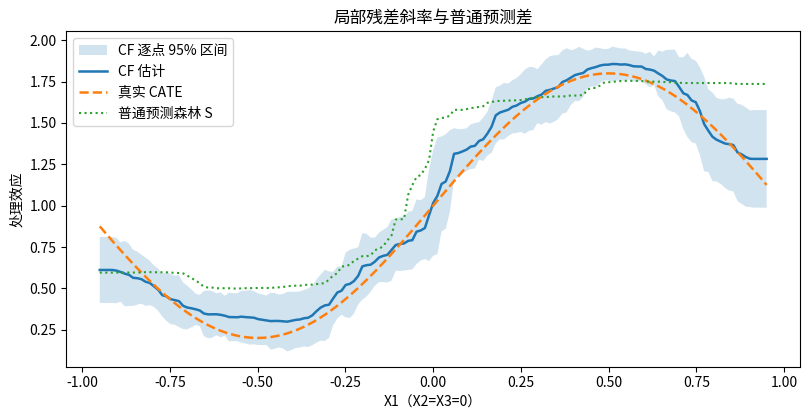

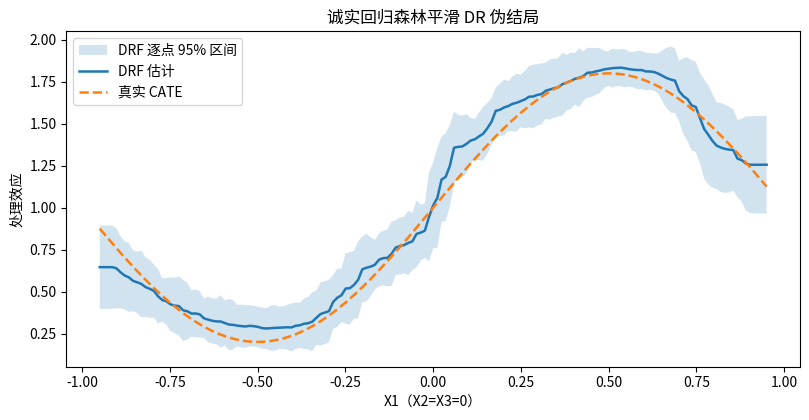

In [9]:
cf_grid, cf_low, cf_high = get_interval(cf, GRID)
drf_grid, drf_low, drf_high = get_interval(drf, GRID)
s_grid = s_effect(s_forest, GRID)

fig, ax = plt.subplots(figsize=(8.2, 4.3))
ax.fill_between(GRID[:, 0], cf_low, cf_high, alpha=0.2, label="CF 逐点 95% 区间")
ax.plot(GRID[:, 0], cf_grid, label="CF 估计", linewidth=1.8)
ax.plot(GRID[:, 0], TAU_GRID, linestyle="--", label="真实 CATE", linewidth=1.8)
ax.plot(GRID[:, 0], s_grid, linestyle=":", label="普通预测森林 S")
ax.set(xlabel="X1（X2=X3=0）", ylabel="处理效应", title="局部残差斜率与普通预测差")
ax.legend()
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8.2, 4.3))
ax.fill_between(GRID[:, 0], drf_low, drf_high, alpha=0.2, label="DRF 逐点 95% 区间")
ax.plot(GRID[:, 0], drf_grid, label="DRF 估计", linewidth=1.8)
ax.plot(GRID[:, 0], TAU_GRID, linestyle="--", label="真实 CATE", linewidth=1.8)
ax.set(xlabel="X1（X2=X3=0）", ylabel="处理效应", title="诚实回归森林平滑 DR 伪结局")
ax.legend()
fig.tight_layout()
plt.show()

两条森林曲线都经过局部平滑。接近弯曲处或边缘时，叶节点里混合了不同的真效应，有限样本平滑偏差不会因为区间计算正确就自动消失。想判断 95% 的覆盖表现，需要反复抽取新的训练样本，而不是看这一张图的真曲线是否大部分落在带内。

## 完整案例二：把森林预测拆回样本权重

### 1. 从树内编号映射回原始样本

`get_subsample_inds()` 给出每棵树抽到的原始行号；树的 `get_train_test_split_inds()` 返回子样本内部编号。必须先将两者对应起来，才能知道哪些原始行在估计叶节点。

下面对三个目标点重建权重。每棵树只使用估计半样本中与目标点同叶的人，结构半样本不直接进入该树的叶节点均值。注意：这是“在每棵树内分开”；同一个人可以在其他树中承担另一种角色。

In [10]:
def kernel_weights(forest,X_train,X_query):
    X_train=np.asarray(X_train,float);X_query=np.asarray(X_query,float)
    if X_train.ndim!=2 or X_query.ndim!=2 or X_train.shape[1]!=X_query.shape[1]:
        raise ValueError('训练特征与目标点需具有相同列数。')
    n=len(X_train);K=np.zeros((len(X_query),n));audit=[]
    subsamples=forest.get_subsample_inds()
    for t,(tree,sub) in enumerate(zip(forest.estimators_,subsamples)):
        if len(np.unique(sub))!=len(sub) or (len(sub) and sub.max()>=n):
            raise ValueError('森林记录的子样本与提供的训练特征不一致。')
        istruct,iest=tree.get_train_test_split_inds()
        # 这两个索引是树子样本内部的编号，须先映射回训练表。
        est=sub[iest];struct=sub[istruct]
        leaves=tree.apply(X_train[est]);query_leaves=tree.apply(X_query)
        for q,leaf in enumerate(query_leaves):
            members=est[leaves==leaf]
            if len(members)==0:raise RuntimeError('目标叶节点没有估计样本。')
            K[q,members]+=1./(len(subsamples)*len(members))
        audit.append(dict(tree=t+1,subsample=len(sub),structure=len(struct),estimation=len(est),intersection=len(np.intersect1d(struct,est))))
    if not np.allclose(K.sum(axis=1),1):raise RuntimeError('森林相似性权重未归一化。')
    return K,pd.DataFrame(audit)

def local_moment(K,a,b):
    K=np.asarray(K,float);a=np.asarray(a,float);b=np.asarray(b,float)
    if K.ndim==1:K=K[None,:]
    if K.shape[1]!=len(a) or len(a)!=len(b) or np.any(K<0) or not all(np.isfinite(z).all() for z in (K,a,b)) or not np.allclose(K.sum(1),1):
        raise ValueError('局部权重必须有限、非负、归一化，且与残差长度一致。')
    q=np.column_stack([b,np.ones(len(b))]);A=np.einsum('kn,ni,n->ki',K,q,a)
    J=np.einsum('kn,ni,nj->kij',K,q,q)
    if np.any(np.linalg.eigvalsh(J)[:,0]<1e-10):raise ValueError('局部处理残差没有足够变异。')
    coefficients=np.linalg.solve(J,A[...,None])[...,0]
    return coefficients,A,J

query = np.array([[-0.7, 0., 0.], [0.35, 0., 0.], [0.8, 0., 0.]])
K_cf, tree_audit = kernel_weights(cf, X, query)
coef_manual, A_manual, J_manual = local_moment(K_cf, a, b)
coef_package = cf.predict_full(query)
K_drf, drf_tree_audit = kernel_weights(drf, X, query)
drf_manual = K_drf @ gamma
drf_package = drf.predict(query)[:, 0]
reconstruction = pd.DataFrame({
    "X1": query[:, 0], "CF手算斜率": coef_manual[:, 0], "CF软件斜率": coef_package[:, 0],
    "CF手算截距": coef_manual[:, 1], "CF软件截距": coef_package[:, 1],
    "DRF手算": drf_manual, "DRF软件": drf_package,
})
display(tree_audit.head())
# 查看第一组树中，目标 x=(0.35,0,0) 所落叶节点的真实估计样本。
leaf_rows = []
for tree_id, (tree, sub) in enumerate(zip(cf.estimators_[:5], cf.get_subsample_inds()[:5]), 1):
    _, local_est = tree.get_train_test_split_inds()
    global_est = sub[local_est]
    leaf_id = int(tree.apply(query[[1]])[0])
    members = global_est[tree.apply(X[global_est]) == leaf_id]
    leaf_rows.append({"树": tree_id, "叶节点编号": leaf_id, "估计人数": len(members),
                      "其中 T=0": int(np.sum(T[members] == 0)),
                      "其中 T=1": int(np.sum(T[members] == 1)),
                      "该树局部斜率": tree.predict(query[[1]])[0, 0]})
display(pd.DataFrame(leaf_rows).round(5))
display(reconstruction.round(9))
np.testing.assert_allclose(coef_manual, coef_package, atol=1e-10, rtol=1e-10)
np.testing.assert_allclose(drf_manual, drf_package, atol=1e-10, rtol=1e-10)
print("最大数值差：", f"CF={np.max(np.abs(coef_manual-coef_package)):.2e}; "
      f"DRF={np.max(np.abs(drf_manual-drf_package)):.2e}")

,tree,subsample,structure,estimation,intersection
0,1,900,450,450,0
1,2,900,450,450,0
2,3,900,450,450,0
3,4,900,450,450,0
4,5,900,450,450,0


,树,叶节点编号,估计人数,其中 T=0,其中 T=1,该树局部斜率
0,1,21,20,10,10,1.65950
1,2,20,33,15,18,1.62416
2,3,24,21,8,13,1.70777
3,4,24,23,4,19,1.79009
4,5,21,22,11,11,1.21990


,X1,CF手算斜率,CF软件斜率,CF手算截距,CF软件截距,DRF手算,DRF软件
0,-0.70,0.383856,0.383856,-0.000279,-0.000279,0.382747,0.382747
1,0.35,1.713414,1.713414,0.023822,0.023822,1.713415,1.713415
2,0.80,1.414368,1.414368,0.019372,0.019372,1.390280,1.390280


最大数值差： CF=2.44e-15; DRF=6.66e-16


表中两个半样本的交集都是零。手算与软件吻合的关键，不是重新写一个“看起来像森林”的模型，而是取出实际森林的叶节点，并按同一矩方程计算。

### 2. 一个目标点究竟借用了哪些人？

取 $x=(0.35,0,0)$，查看权重最大的若干训练样本。用

$$
 n_{\mathrm{eff}}(x)=\frac1{\sum_i\alpha_i(x)^2}
$$

描述权重集中程度。这个数只是相似性权重的有效样本量，不能单独用来计算因果森林标准误。局部处理变异、结局噪声和树的依赖也重要。

矩阵 $J$ 的 Schur 补为

$$
\sum_i\alpha_i b_i^2-\left(\sum_i\alpha_i b_i\right)^2,
$$

即局部处理残差的加权方差。它很小时，同一邻域缺少可用于比较的处理变化。

,X1,X2,X3,T,Y,相似性权重,处理残差 b
1993,0.33183,0.00174,0.07846,0,1.36104,0.00875,-0.59452
1297,0.32663,0.03172,0.04634,1,3.76683,0.00732,0.40482
20,0.33681,-0.05781,0.13047,0,2.24304,0.00677,-0.57154
1565,0.33717,-0.19958,-0.04301,0,1.45692,0.00634,-0.55313
1076,0.29619,-0.03298,-0.12130,1,3.95612,0.00563,0.40871
574,0.42384,0.12705,-0.00879,1,3.22926,0.00541,0.35802
900,0.37750,0.06548,-0.22427,1,2.82122,0.00529,0.36792
69,0.35532,-0.75633,0.01266,1,1.07653,0.00492,0.58826
978,0.33367,-0.05642,-0.35683,0,1.85776,0.00492,-0.60834
1377,0.25363,-0.14514,0.02065,0,2.48976,0.00475,-0.54165


,X1,正权重人数,权重 ESS,局部处理残差方差
0,-0.70,899,423.77810,0.2210
1,0.35,865,415.37519,0.2251
2,0.80,641,294.24543,0.2032


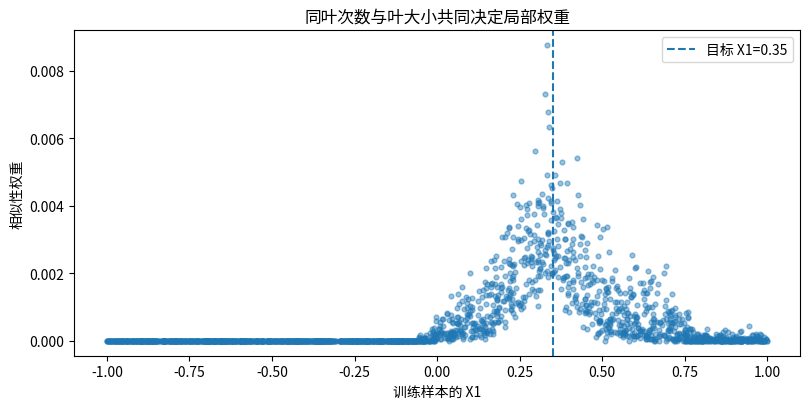

,CF 效应分裂重要性,DRF 伪结局分裂重要性,预测森林的 X 重要性
X1,0.9936,0.994,0.0936
X2,0.0032,0.003,0.7322
X3,0.0032,0.003,0.0262


预测森林另外赋给处理 T 的重要性： 0.148


In [11]:
q_index = 1
weights = K_cf[q_index]
top_index = np.argsort(-weights, kind="stable")[:10]
local_view = observed.iloc[top_index].copy()
local_view["相似性权重"] = weights[top_index]
local_view["处理残差 b"] = b[top_index]
display(local_view.round(5))
local_diagnostics = pd.DataFrame({
    "X1": query[:, 0], "正权重人数": (K_cf > 0).sum(axis=1),
    "权重 ESS": 1/np.sum(K_cf**2, axis=1),
    "局部处理残差方差": J_manual[:, 0, 0]-J_manual[:, 0, 1]**2,
})
display(local_diagnostics.round(5))

fig, ax = plt.subplots(figsize=(8.2, 4.2))
ax.scatter(X[:, 0], weights, s=12, alpha=0.45)
ax.axvline(query[q_index, 0], linestyle="--", label="目标 X1=0.35")
ax.set(xlabel="训练样本的 X1", ylabel="相似性权重", title="同叶次数与叶大小共同决定局部权重")
ax.legend()
fig.tight_layout()
plt.show()

importance = pd.DataFrame({
    "CF 效应分裂重要性": cf.feature_importances_,
    "DRF 伪结局分裂重要性": drf.feature_importances_,
    "预测森林的 X 重要性": s_forest.feature_importances_[:3],
}, index=X_COLS)
display(importance.round(4))
print("预测森林另外赋给处理 T 的重要性：", round(s_forest.feature_importances_[3], 4))

在本例中，解释基线的变量与解释效应的变量并不相同。表中的重要性依赖各自的分裂准则、尺度和模型，不是可以相减比较的同一种因果量，更不是“干预这个特征会带来多大作用”。这里只用它检查模型是否把切分资源放在模拟中的相关维度上。

## 完整案例三：区间是否真有 95% 覆盖率？

固定五个检查位置，独立生成新的训练样本，每次重新交叉拟合四个辅助模型、重新构造两种森林，再计算预测和区间。森林随机种子随重复改变，既计入数据波动，也计入有限树数的随机性。

这里每次使用 160 棵树，以控制运行时间；主案例使用 400 棵。重复模拟的区间是这套明确配置的区间，不把两套配置混作同一个实验。

对任一固定 $x$，记录偏差、估计值的经验标准差、平均报告标准误和覆盖率。覆盖率为

$$
\widehat c(x)=\frac1R\sum_{r=1}^R
\mathbf 1\{\tau(x)\in[\widehat L_r(x),\widehat U_r(x)]\}.
$$

其 Monte Carlo 标准误约为 $\sqrt{\widehat c(x)(1-\widehat c(x))/R}$。另外记录五点同时覆盖的比例，但并没有给逐点区间做同时性修正，不要求它达到 95%。

In [12]:
# 使用同一份独立测试特征评价所有重复，控制测试集 Monte Carlo 波动。
# 它从不进入任何 fit，也不按测试结果选择参数。
mc_point_rows = []
mc_risk_rows = []
mc_curve_store = {}
for n in SAMPLE_SIZES:
    for method in ("CF", "DRF"):
        mc_curve_store[(n, method)] = []
    for rep in range(N_REPEATS):
        train_rep, _ = make_data(n, SEED_REPEAT + 100000*n + rep)
        xr = train_rep[X_COLS].to_numpy()
        tr = train_rep["T"].to_numpy()
        yr = train_rep["Y"].to_numpy()
        pr, _, _ = crossfit_nuisance(xr, tr, yr, N_FOLDS, 6200+rep, CLIP)
        ar, br, gr = signals(tr, yr, pr)
        forests = fit_forests(xr, ar, br, gr, N_MC_TREES, min_leaf=15, seed=6300+rep)
        for method, forest in zip(("CF", "DRF"), forests):
            point, lower, upper = get_interval(forest, CHECK_POINTS)
            hit = (lower <= TAU_CHECK) & (TAU_CHECK <= upper)
            for j, x1 in enumerate(CHECK_POINTS[:, 0]):
                mc_point_rows.append({
                    "n": n, "rep": rep, "method": method, "X1": x1,
                    "estimate": point[j], "truth": TAU_CHECK[j],
                    "se": (upper[j]-lower[j])/(2*Z_CRIT), "covered": bool(hit[j]),
                })
            curve = forest.predict(GRID)[:, 0]
            mc_curve_store[(n, method)].append(curve)
            test_prediction = forest.predict(X_test)[:, 0]
            mc_risk_rows.append({
                "n": n, "rep": rep, "method": method,
                "test_mse": np.mean((test_prediction-test_truth["tau"])**2),
                "grid_mse": np.mean((curve-TAU_GRID)**2),
                "all_five_covered": bool(np.all(hit)),
            })
mc_points = pd.DataFrame(mc_point_rows)
mc_risk = pd.DataFrame(mc_risk_rows)
for key in mc_curve_store:
    mc_curve_store[key] = np.asarray(mc_curve_store[key])
print(f"完成 {len(SAMPLE_SIZES)*N_REPEATS} 份独立训练样本；每份重拟合 CF 与 DRF。")

完成 240 份独立训练样本；每份重拟合 CF 与 DRF。


先看各个点，不把位置不同的覆盖率合成一个好看的总数。偏差相对于标准误越大，零均值正态近似越容易失准；较多树能减少森林本身的随机波动，却不能直接消除平滑偏差与辅助预测误差。

,n,方法,X1,偏差,经验标准差,平均报告 SE,覆盖率,覆盖率 MCSE,MC下界,MC上界
0,800,CF,-0.8,0.0326,0.1202,0.1190,0.9083,0.0263,0.8433,0.9480
1,800,CF,-0.4,0.1774,0.0878,0.0958,0.5750,0.0451,0.4856,0.6598
2,800,CF,0.0,0.0032,0.1580,0.1464,0.8750,0.0302,0.8040,0.9228
3,800,CF,0.4,-0.1664,0.0932,0.0947,0.5250,0.0456,0.4363,0.6122
4,800,CF,0.8,-0.0218,0.1091,0.1180,0.9500,0.0199,0.8952,0.9769
5,800,DRF,-0.8,0.0495,0.1391,0.1327,0.9333,0.0228,0.8739,0.9658
6,800,DRF,-0.4,0.1747,0.0908,0.0985,0.5667,0.0452,0.4773,0.6519
7,800,DRF,0.0,0.0002,0.1562,0.1537,0.9000,0.0274,0.8333,0.9419
8,800,DRF,0.4,-0.1691,0.0863,0.0974,0.5833,0.0450,0.4939,0.6676
9,800,DRF,0.8,-0.0337,0.1260,0.1261,0.9417,0.0214,0.8845,0.9715


,n,方法,测试 MSE,MSE 的 MCSE,五点同时覆盖比例
0,800,CF,0.03578,0.00083,0.25000
1,800,DRF,0.03694,0.00085,0.25833
2,2400,CF,0.01441,0.00043,0.57500
3,2400,DRF,0.01473,0.00043,0.57500


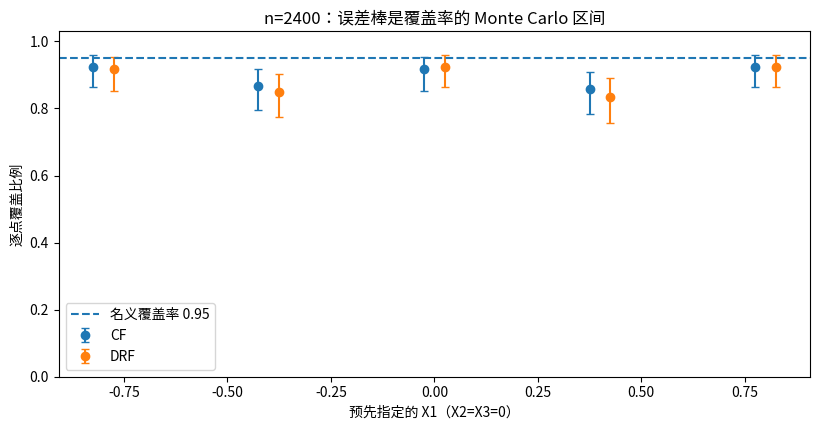

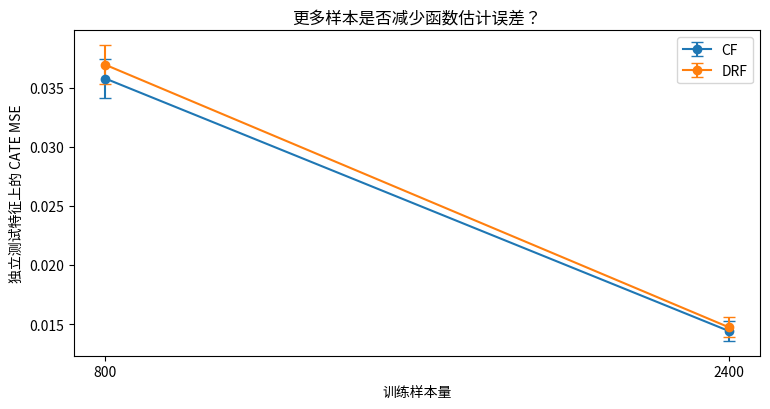

In [13]:
point_summary_rows = []
for (n, method, x1), part in mc_points.groupby(["n", "method", "X1"], sort=True):
    low, high = wilson(int(part.covered.sum()), len(part))
    coverage = part.covered.mean()
    point_summary_rows.append({
        "n": n, "方法": method, "X1": x1,
        "偏差": np.mean(part.estimate-part.truth), "经验标准差": part.estimate.std(ddof=1),
        "平均报告 SE": part.se.mean(), "覆盖率": coverage,
        "覆盖率 MCSE": np.sqrt(coverage*(1-coverage)/len(part)),
        "MC下界": low, "MC上界": high,
    })
point_summary = pd.DataFrame(point_summary_rows)
display(point_summary.round(4))

risk_rows = []
for (n, method), part in mc_risk.groupby(["n", "method"]):
    risk_rows.append({"n": n, "方法": method, "测试 MSE": part.test_mse.mean(),
                      "MSE 的 MCSE": part.test_mse.std(ddof=1)/np.sqrt(len(part)),
                      "五点同时覆盖比例": part.all_five_covered.mean()})
risk_summary = pd.DataFrame(risk_rows)
display(risk_summary.round(5))

fig, ax = plt.subplots(figsize=(8.3, 4.4))
for method, shift in [("CF", -0.025), ("DRF", 0.025)]:
    part = point_summary[(point_summary["n"] == max(SAMPLE_SIZES)) & (point_summary["方法"] == method)]
    ax.errorbar(part.X1+shift, part["覆盖率"],
                yerr=np.vstack([part["覆盖率"]-part["MC下界"], part["MC上界"]-part["覆盖率"]]),
                fmt="o", capsize=3, label=method)
ax.axhline(0.95, linestyle="--", label="名义覆盖率 0.95")
ax.set(xlabel="预先指定的 X1（X2=X3=0）", ylabel="逐点覆盖比例", ylim=(0, 1.03),
       title=f"n={max(SAMPLE_SIZES)}：误差棒是覆盖率的 Monte Carlo 区间")
ax.legend()
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7.8, 4.2))
for method in ("CF", "DRF"):
    part = risk_summary[risk_summary["方法"] == method]
    ax.errorbar(part.n, part["测试 MSE"], yerr=Z_CRIT*part["MSE 的 MCSE"],
                marker="o", capsize=4, label=method)
ax.set(xlabel="训练样本量", ylabel="独立测试特征上的 CATE MSE", title="更多样本是否减少函数估计误差？")
ax.set_xticks(list(SAMPLE_SIZES))
ax.legend()
fig.tight_layout()
plt.show()

默认参数下，800 人时 CF 在 $X_1=-0.4,0.4$ 的覆盖率分别为 57.5% 和 52.5%，明显不足。对应偏差约为 $0.18,-0.17$，已经大于平均报告标准误；叶节点把谷底向上、峰顶向下平滑，区间却没有补偿这部分偏差。不能只看平均报告 SE 与经验标准差相近，就认为区间可靠。

增加到 2,400 人，测试 MSE 下降，但这两个位置的覆盖率仍约为 86.7% 和 85.8%。这些数字只对应上面的默认参数和随机种子，修改配置后以重新运行结果为准。书中对森林区间的理论条件和实际局限已有专门讨论；本例正好说明，诚实划分和专门的方差估计仍不能替代对近似偏差的检查。[2，正文第 387–388 页]

进一步将同一网格上的均方误差分解为偏差平方与方差。这里用分母 $R$ 计算重复间方差，使下面的有限次模拟恒等式精确成立：

$$
\frac1R\sum_r[\widehat\tau_r(x)-\tau(x)]^2
=[\overline{\widehat\tau}(x)-\tau(x)]^2
+\frac1R\sum_r[\widehat\tau_r(x)-\overline{\widehat\tau}(x)]^2.
$$

该图仍然是条件于 $X_2=X_3=0$ 的切片诊断；前表的测试 MSE 则在独立生成的完整三维特征上平均。

,n,方法,网格 MSE,平均偏差平方,平均方差
0,800,CF,0.028307,0.017148,0.011159
1,800,DRF,0.028832,0.016806,0.012026
2,2400,CF,0.009919,0.002748,0.007171
3,2400,DRF,0.010081,0.002729,0.007352


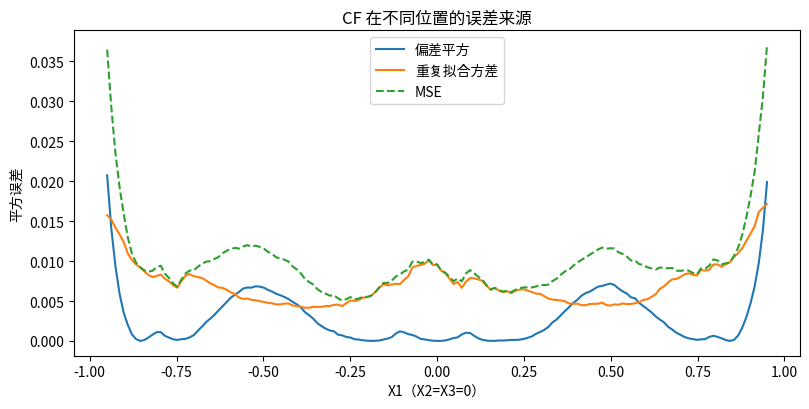

In [14]:
decomposition_rows = []
for (n, method), curves in mc_curve_store.items():
    squared_bias = (curves.mean(axis=0)-TAU_GRID)**2
    variance = curves.var(axis=0, ddof=0)
    mse = ((curves-TAU_GRID)**2).mean(axis=0)
    np.testing.assert_allclose(mse, squared_bias+variance, atol=1e-12)
    decomposition_rows.append({"n": n, "方法": method, "网格 MSE": mse.mean(),
                               "平均偏差平方": squared_bias.mean(), "平均方差": variance.mean()})
decomposition = pd.DataFrame(decomposition_rows)
display(decomposition.round(6))

curves = mc_curve_store[(max(SAMPLE_SIZES), "CF")]
fig, ax = plt.subplots(figsize=(8.2, 4.2))
ax.plot(GRID[:, 0], (curves.mean(axis=0)-TAU_GRID)**2, label="偏差平方")
ax.plot(GRID[:, 0], curves.var(axis=0, ddof=0), label="重复拟合方差")
ax.plot(GRID[:, 0], ((curves-TAU_GRID)**2).mean(axis=0), linestyle="--", label="MSE")
ax.set(xlabel="X1（X2=X3=0）", ylabel="平方误差", title="CF 在不同位置的误差来源")
ax.legend()
fig.tight_layout()
plt.show()

## 模型分析

### 1. 辅助函数完全已知，低重叠也不会消失

为了单独观察局部信息量，下一段直接使用模拟中的真实 $e,\mu_0,\mu_1,\ell$，不再学习辅助函数。它是不可在真实数据上照做的 oracle 实验。

把处理评分改为 $\operatorname{expit}\{c(0.8X_1+0.8X_2-0.4X_3)\}$，比较 $c=1$ 与 $c=4$。两次使用相同特征、潜在结局噪声与处理分配的均匀随机数，只改变评分。效应函数不变。

查看局部残差方差、权重 ESS、误差与区间宽度。即使辅助函数没有估计误差，在处理几乎确定的邻域中，也只有很少的“相反处理”信息。森林可能借用更远邻域，降低方差的同时增加平滑偏差；单次拟合的宽度不必处处单调变化。

,评分强度 c,X1,真实评分,预测误差,区间宽度,相似性 ESS,局部残差方差
0,1.0,-0.8,0.34525,0.08912,0.25781,419.93030,0.21939
1,1.0,-0.4,0.42068,0.14047,0.19673,483.93404,0.23612
2,1.0,0.0,0.50000,-0.10006,0.36449,410.51816,0.22932
3,1.0,0.4,0.57932,-0.01457,0.25845,415.30115,0.23504
4,1.0,0.8,0.65475,0.03232,0.46574,456.48735,0.21218
5,4.0,-0.8,0.07176,0.03248,0.54598,469.08176,0.07542
6,4.0,-0.4,0.21755,0.18511,0.41306,486.05027,0.12893
7,4.0,0.0,0.50000,-0.11892,0.38461,456.25554,0.14849
8,4.0,0.4,0.78245,-0.02704,0.47770,430.12329,0.13076
9,4.0,0.8,0.92824,0.21944,0.51237,464.31017,0.08047


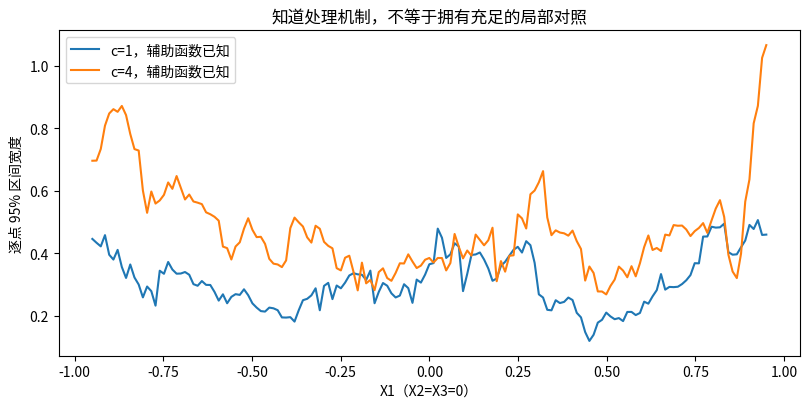

In [15]:
overlap_rows = []
overlap_fits = {}
for strength in (1., 4.):
    obs_o, truth_o = make_data(3000, 7300, overlap=strength)
    xo = obs_o[X_COLS].to_numpy()
    to = obs_o["T"].to_numpy()
    yo = obs_o["Y"].to_numpy()
    ao = yo-truth_o["ell"]
    bo = to-truth_o["e"]
    cf_o = CausalForest(
        criterion="het", fit_intercept=True, min_var_fraction_leaf=0.05,
        **forest_parameters(N_TREES, min_leaf=20, seed=SEED_FOREST),
    ).fit(xo, bo, ao)
    po, lo, uo = get_interval(cf_o, CHECK_POINTS)
    ko, _ = kernel_weights(cf_o, xo, CHECK_POINTS)
    _, _, jo = local_moment(ko, ao, bo)
    for j, x1 in enumerate(CHECK_POINTS[:, 0]):
        overlap_rows.append({
            "评分强度 c": strength, "X1": x1, "真实评分": expit(strength*0.8*x1),
            "预测误差": po[j]-TAU_CHECK[j], "区间宽度": uo[j]-lo[j],
            "相似性 ESS": 1/np.sum(ko[j]**2),
            "局部残差方差": jo[j, 0, 0]-jo[j, 0, 1]**2,
        })
    overlap_fits[strength] = (cf_o, get_interval(cf_o, GRID), xo, to, yo)
overlap_table = pd.DataFrame(overlap_rows)
display(overlap_table.round(5))

fig, ax = plt.subplots(figsize=(8.2, 4.2))
for strength, (_, (_, lo, up), _, _, _) in overlap_fits.items():
    ax.plot(GRID[:, 0], up-lo, label=f"c={strength:g}，辅助函数已知")
ax.set(xlabel="X1（X2=X3=0）", ylabel="逐点 95% 区间宽度", title="知道处理机制，不等于拥有充足的局部对照")
ax.legend()
fig.tight_layout()
plt.show()

### 2. 多种树，不是多收集几份数据

再固定主样本及其折外残差，只增加树数。对一个预先固定的点，比较软件报告的标准误与一个常见但错误的替代量：

$$
\frac{\operatorname{sd}(\widehat\tau_1(x),\ldots,\widehat\tau_B(x))}{\sqrt B}.
$$

后一式把树当成独立的完整数据集。事实上，各树共享训练样本，且 GRF 最终结果也并非树斜率的简单平均。增加树数主要减少算法随机波动，不能让固定样本中的抽样不确定性任意趋于零。

本实验不是选择“区间最窄”的树数；只是展示两种标准误概念的区别。

,树数,森林预测,软件 SE,错误替代量 sd/sqrt(B)
0,80,1.767438,0.065287,0.029182
1,320,1.716955,0.102900,0.014253
2,1280,1.718506,0.084837,0.006710


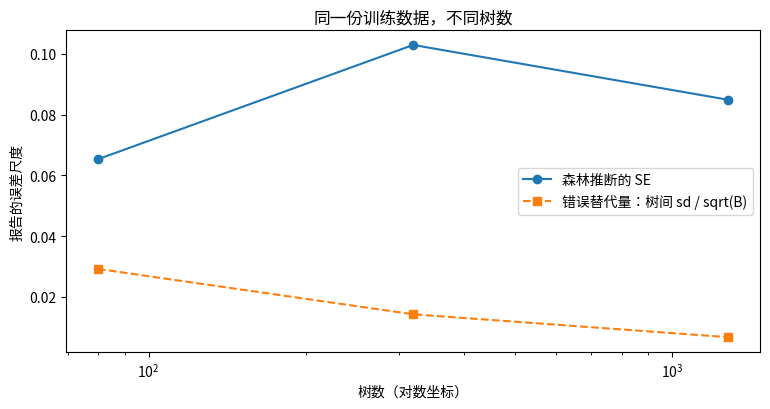

In [16]:
tree_number_rows = []
q_fixed = np.array([[0.35, 0., 0.]])
for tree_count in (80, 320, 1280):
    forest_b = CausalForest(
        criterion="het", fit_intercept=True, min_var_fraction_leaf=0.05,
        **forest_parameters(tree_count, min_leaf=20, seed=SEED_FOREST),
    ).fit(X, b, a)
    p_b, lo_b, hi_b = get_interval(forest_b, q_fixed)
    tree_slopes = np.array([tree.predict(q_fixed)[0, 0] for tree in forest_b.estimators_])
    tree_number_rows.append({"树数": tree_count, "森林预测": p_b[0],
                            "软件 SE": (hi_b[0]-lo_b[0])/(2*Z_CRIT),
                            "错误替代量 sd/sqrt(B)": tree_slopes.std(ddof=1)/np.sqrt(tree_count)})
tree_number_table = pd.DataFrame(tree_number_rows)
display(tree_number_table.round(6))

fig, ax = plt.subplots(figsize=(7.8, 4.2))
ax.plot(tree_number_table["树数"], tree_number_table["软件 SE"], marker="o", label="森林推断的 SE")
ax.plot(tree_number_table["树数"], tree_number_table["错误替代量 sd/sqrt(B)"], marker="s",
        linestyle="--", label="错误替代量：树间 sd / sqrt(B)")
ax.set(xscale="log", xlabel="树数（对数坐标）", ylabel="报告的误差尺度", title="同一份训练数据，不同树数")
ax.legend()
fig.tight_layout()
plt.show()

## 练习

### 练习一：平均斜率，还是平均矩方程？

构造两个叶邻域：第一棵树使用前两行，第二棵使用后两行。每个邻域中 $a,b$ 都中心化，局部斜率分别为 1 和 3：

$$
b=(-0.5,0.5,-1,1),\qquad a=(-0.5,0.5,-3,3).
$$

两棵树各占一半。分别计算树斜率均值、合并森林权重后的斜率，以及直接最小二乘结果。为什么叶大小相同仍然不能简单平均斜率？

参考计算如下。先分别求矩，再汇总求解。

In [17]:
b_ex = np.array([-0.5, 0.5, -1., 1.])
a_ex = np.array([-0.5, 0.5, -3., 3.])
K_tree = np.array([[0.5, 0.5, 0., 0.], [0., 0., 0.5, 0.5]])
individual_coef, individual_A, individual_J = local_moment(K_tree, a_ex, b_ex)
K_pool = K_tree.mean(axis=0)
pooled_coef, pooled_A, pooled_J = local_moment(K_pool, a_ex, b_ex)
ols_coef = np.linalg.lstsq(np.column_stack([b_ex, np.ones(4)]), a_ex, rcond=None)[0]
display(pd.DataFrame({
    "计算": ["树斜率的简单平均", "汇总矩方程", "四行等权 OLS"],
    "斜率": [individual_coef[:, 0].mean(), pooled_coef[0, 0], ols_coef[0]],
}))
np.testing.assert_allclose(pooled_A[0], individual_A.mean(axis=0))
np.testing.assert_allclose(pooled_J[0], individual_J.mean(axis=0))
np.testing.assert_allclose(pooled_coef[0], ols_coef, atol=1e-12)
np.testing.assert_allclose(pooled_coef[0, 0], 2.6)

,计算,斜率
0,树斜率的简单平均,2.0
1,汇总矩方程,2.6
2,四行等权 OLS,2.6


简单平均为 2，合并矩方程得到 2.6。第二个邻域的处理残差方差更大，对局部斜率提供的信息不同。一般地，先求逆再平均与先平均再求逆不相等；DR 森林的均值矩比较特殊，才会退化为普通树预测平均。

### 练习二：CATE 的 95% 区间能用于个人效应吗？

固定 $x=(-0.8,0,0)$，其 CATE 为 $1+0.8\sin(-0.8\pi)$，单个潜在结局的条件标准差为 $\sigma=0.5(1+0.4\times0.8^2)$。

考虑两种潜在结局联合分布：一是两种结局噪声完全相同；二是噪声相互独立。它们的 $Y(0)\mid X$ 与 $Y(1)\mid X$ 边缘分布相同，因此配合相同分配机制，产生相同的观察数据分布；CATE 也相同。但个人效应的分布不一样。[1，第 2、4 章]

算出两种设定下的个人效应标准差、中央 95% 范围及获益概率。下列范围来自额外指定的模拟联合分布，不是从一份观察数据识别出来的结果，也不是森林输出的 CATE 区间。

In [18]:
x1_ex = -0.8
tau_ex = 1 + 0.8*np.sin(np.pi*x1_ex)
sigma_ex = 0.5*(1+0.4*x1_ex**2)
individual_rows = []
for correlation, label in [(1., "两种潜在噪声完全相同"), (0., "两种潜在噪声独立")]:
    ite_sd = np.sqrt(2*(1-correlation))*sigma_ex
    benefit_probability = float(tau_ex > 0) if ite_sd == 0 else norm.cdf(tau_ex/ite_sd)
    individual_rows.append({
        "联合分布假设": label, "CATE": tau_ex, "个人效应 SD": ite_sd,
        "个人效应中央95%下界": tau_ex-Z_CRIT*ite_sd,
        "个人效应中央95%上界": tau_ex+Z_CRIT*ite_sd,
        "P(Y1>Y0 | X)": benefit_probability,
    })
display(pd.DataFrame(individual_rows).round(5))
p_ex, l_ex, u_ex = get_interval(cf, np.array([[x1_ex, 0., 0.]]))
print("本次 CF 的 CATE 估计和逐点区间：", np.round([p_ex[0], l_ex[0], u_ex[0]], 5))

,联合分布假设,CATE,个人效应 SD,个人效应中央95%下界,个人效应中央95%上界,P(Y1>Y0 | X)
0,两种潜在噪声完全相同,0.52977,0.00000,0.52977,0.52977,1.00000
1,两种潜在噪声独立,0.52977,0.88813,-1.21092,2.27047,0.72458


本次 CF 的 CATE 估计和逐点区间： [0.51757 0.38946 0.64568]


个人效应的范围会随两个潜在结局的相关性改变，而森林只看到了每个人的一种结局。样本量增加可以让 CATE 估计更精确，却不会凭空识别这两个潜在结局的联合分布。

## 总结与适用范围

本篇只需记住三处变化。第一，分裂目标从结局预测转为效应异质性；第二，树结构与叶节点估计使用不同样本，且它不替代第一阶段交叉拟合；第三，因果森林先形成邻域权重，再求解局部矩方程。

DR 森林在伪结局上做局部均值，残差型 CF 在局部残差上估计斜率。它们可能给出相近曲线，也可能在低重叠和模型近似误差下表现不同。主分析用了完整 $X$；若只把少量变量传入效应森林，却漏掉仍会修饰效应的变量，残差矩不再自动对应所报告子集的普通 CATE。这个目标问题与上一篇的 R-Learner 一致。[2，正文第 389–391 页]

逐点区间要连同样本量、局部支持、辅助预测误差和森林参数一起解释。这里重复模拟没有把覆盖率不足隐藏掉。真实研究还需要独立的模型评价，不能仅凭效应曲线起伏、特征重要性或训练集上的分组差异，认定已经发现可靠异质性。

## 参考资料

[1] Peng Ding. *A First Course in Causal Inference*. 上传版本：arXiv:2305.18793v2，2023-10-03。第 2 章、第 4 章与第 10.3 节。

[2] Victor Chernozhukov, Christian Hansen, Nathan Kallus, Martin Spindler, Vasilis Syrgkanis. *Applied Causal Inference Powered by ML and AI*. 上传版本：2026-05-03，Version 0.1.2。第 14.3 节（PDF 第 395–401 页，正文第 385–391 页）为本篇主体；第 15.1 节用于衔接 DR/R 学习。

版本注：该书正文第 390 页末，先定义 $p_0(Z)=E[D\mid Z]$、$q_0(Z)=E[Y\mid Z]$，随后写两侧样本残差时将 $p,q$ 对调。本篇不沿用该处符号，始终按前面的式 (14.3.4) 使用 $a=Y-\widehat\ell(X)$、$b=T-\widehat e(X)$。局部矩的计算还包含正文第 391 页提出的截距。

[3] Susan Athey, Guido Imbens. Recursive partitioning for heterogeneous causal effects. *PNAS*, 2016, 113(27):7353–7360. DOI: 10.1073/pnas.1510489113。用于补充诚实因果树的原始方法；本篇树桩不是其完整算法复现。

[4] EconML. `econml.grf.CausalForest` 接口及源代码。https://www.pywhy.org/EconML/_autosummary/econml.grf.CausalForest.html 。线上文档页仍标记 0.16.0；本篇实际计算使用 0.17.0，关键结果通过已安装实现中的树记录独立重算，不依赖默认参数。

[5] EconML. `econml.grf.RegressionForest` 接口及源代码。https://www.pywhy.org/EconML/_autosummary/econml.grf.RegressionForest.html 。DR 森林由诚实回归森林与本篇手算的折外 DR 标签组合。

### 本次运行环境说明

实际测试使用 EconML 0.17.0 官方仓库的发布源代码构建件。受当前运行环境的依赖下载限制，仅在测试环境对 `utilities.py` 中未使用的 `pydata/sparse` 导入加了兼容检查；没有修改森林分裂、预测、权重或区间算法。全部计算使用 NumPy 稠密数组，未测试稀疏数组路径。Notebook 自身不包含该补丁；在本地按开头命令安装完整依赖即可。精确版本、运行状态和复现核对记录另保存在 Notebook 元数据中。